In [1]:
!pip install spectral tqdm scikit-learn

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 12.3 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
import os
import numpy as np
import tensorflow as tf
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import spectral

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score

from tensorflow.keras.layers import (
    Input, Conv3D, Conv2D, Dense, Dropout, Reshape,
    Concatenate, Add, GlobalAveragePooling2D,
    GlobalMaxPooling2D, Permute, Multiply
)
from tensorflow.keras.models import Model

In [3]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("Mixed Precision:", mixed_precision.global_policy())

Mixed Precision: <DTypePolicy "mixed_float16">


In [4]:
def loadData(name):

    data_path = '/content/drive/MyDrive/datasets'

    if name == 'Tangdaowan':
        data = loadmat(os.path.join(data_path, 'QUH-Tangdaowan.mat'))['Tangdaowan']
        labels = loadmat(os.path.join(data_path, 'QUH-Tangdaowan_GT.mat'))['TangdaowanGT']
        class_name = [
            "Rubber track","Flaggingv","Sandy","Asphalt","Boardwalk",
            "Rocky shallows","Grassland","Bulrush","Gravel road",
            "Ligustrum vicaryi","Coniferous pine","Spiraea","Bare soil",
            "Buxus sinica","Photinia serrulata","Populus",
            "Ulmus pumila L","Seawater"
        ]

    elif name == 'Qingyun':
        data = loadmat(os.path.join(data_path, 'QUH-Qingyun.mat'))['Chengqu']
        labels = loadmat(os.path.join(data_path, 'QUH-Qingyun_GT.mat'))['ChengquGT']
        class_name = [
            "Trees","Concrete building","Car",
            "Ironhide building","Plastic playground","Asphalt road"
        ]

    elif name == 'Pingan':
        data = loadmat(os.path.join(data_path, 'QUH-Pingan.mat'))['Haigang']
        labels = loadmat(os.path.join(data_path, 'QUH-Pingan_GT.mat'))['HaigangGT']
        class_name = [
            "Ship","Seawater","Trees","Concrete structure building",
            "Floating pier","Asphalt road","Brick houses",
            "Steel houses","Wharf construction land","Car","Road"
        ]

    return data, labels, class_name

In [5]:
def applyPCA(X, numComponents=15):

    newX = np.reshape(X, (-1, X.shape[2]))

    pca = PCA(n_components=numComponents)

    newX = pca.fit_transform(newX)

    newX = minmax_scale(newX, axis=1)

    newX = np.reshape(newX,(X.shape[0],X.shape[1],numComponents))

    return newX

In [6]:
def get_img_indexes(class_map, removeZeroindexes=True):

    if removeZeroindexes:
        indices = np.argwhere(class_map != 0)
    else:
        indices = np.argwhere(class_map != None)

    labels = class_map[indices[:,0], indices[:,1]]

    indices = [tuple(i) for i in indices]

    return indices, np.array(labels.tolist()) - 1

In [7]:
def splitTrainTestSet(X, y, testRatio):

    return train_test_split(
        X,
        y,
        test_size=testRatio,
        stratify=y,
        random_state=42
    )

In [8]:
def createImageCubes(X, indices, windowSize):

    margin = windowSize // 2

    N,M,P = X.shape

    X_padded = np.zeros((N+2*margin, M+2*margin, P))

    X_padded[margin:N+margin, margin:M+margin,:] = X

    patches = []

    for idx in indices:

        i,j = idx

        i += margin
        j += margin

        patch = X_padded[i-margin:i+margin+1, j-margin:j+margin+1,:]

        patches.append(patch)

    patches = np.array(patches)

    patches = patches[..., np.newaxis]

    return patches

In [9]:
def spectral_mixer_block(x, hidden_dim, num_blocks=2):

    H,W,C,D = x.shape[1:]

    x = Permute((1,2,4,3))(x)

    x = Reshape((H*W, D, C))(x)

    for _ in range(num_blocks):

        x1 = Dense(hidden_dim, activation='gelu')(x)

        x1 = Dense(C)(x1)

        x = Add()([x,x1])

    return Reshape((H,W,C,D))(x)

In [10]:
def spatial_mixer_block(x, hidden_dim, num_blocks=2):

    H,W,C,D = x.shape[1:]

    x = Permute((3,4,1,2))(x)

    x = Reshape((C,D,H*W))(x)

    for _ in range(num_blocks):

        x1 = Dense(hidden_dim, activation='gelu')(x)

        x1 = Dense(H*W)(x1)

        x = Add()([x,x1])

    x = Permute((3,1,2))(x)

    return Reshape((H,W,C,D))(x)

In [11]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Reshape, Multiply, Add,
    Conv2D, Concatenate, Lambda
)

def cbam_block(x, reduction=4):

    channels = x.shape[-1]

    # -----------------------------
    # Channel Attention
    # -----------------------------
    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    avg_pool = Reshape((1,1,channels))(avg_pool)
    max_pool = Reshape((1,1,channels))(max_pool)

    shared_dense1 = Dense(channels // reduction, activation='gelu')
    shared_dense2 = Dense(channels)

    avg_out = shared_dense2(shared_dense1(avg_pool))
    max_out = shared_dense2(shared_dense1(max_pool))

    channel_attention = Add()([avg_out, max_out])
    channel_attention = tf.keras.activations.sigmoid(channel_attention)

    x = Multiply()([x, channel_attention])

    # -----------------------------
    # Spatial Attention
    # -----------------------------
    avg_pool = Lambda(lambda z: tf.reduce_mean(z, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda z: tf.reduce_max(z, axis=-1, keepdims=True))(x)

    spatial = Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = Conv2D(
        filters=1,
        kernel_size=7,
        padding='same',
        activation='sigmoid'
    )(spatial)

    x = Multiply()([x, spatial_attention])

    return x

In [12]:
def SS_MixNet(img_list, num_classes, mixer_dim=256):

    input_shape = img_list.shape[1:]

    inp = Input(shape=input_shape)

    x = Conv3D(32,(3,3,3),padding='same',activation='gelu')(inp)

    x = Conv3D(64,(3,3,3),padding='same',activation='gelu')(x)

    x_spe = spectral_mixer_block(x, mixer_dim)

    x_spa = spatial_mixer_block(x, mixer_dim)

    x = Concatenate(axis=4)([x_spe,x_spa])

    H,W,C,F = x.shape[1:]

    x = Reshape((H,W,C*F))(x)

    x = cbam_block(x)

    res = Conv2D(x.shape[-1],1,padding='same',activation='gelu')(x)

    x = Add()([x,res])

    x = GlobalAveragePooling2D()(x)

    x = Dropout(0.4)(x)

    out = Dense(num_classes,activation='softmax',dtype='float32')(x)

    model = Model(inp,out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy']
    )

    return model

In [13]:
DATASET = 'Tangdaowan'

data, gt, class_name = loadData(DATASET)

print(data.shape)

(1740, 860, 176)


In [14]:
data = applyPCA(data, numComponents=15)

In [15]:
indexes, labels = get_img_indexes(gt)

X_train_idx, X_test_idx, y_train, y_test = splitTrainTestSet(indexes,labels,0.95)

X_train_idx, X_val_idx, y_train, y_val = splitTrainTestSet(X_train_idx,y_train,0.30)

In [16]:
window_size = 9

X_train = createImageCubes(data,X_train_idx,window_size)

X_val = createImageCubes(data,X_val_idx,window_size)

y_train = tf.keras.utils.to_categorical(y_train)

y_val = tf.keras.utils.to_categorical(y_val)

In [17]:
model = SS_MixNet(
    X_train,
    num_classes=len(class_name),
    mixer_dim=256
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9, 9, 15,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 9, 9, 15,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 9, 9, 15,  │     55,360 │ conv3d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 15, 64, 9, │          0 │ conv3d_1[0][0]    │
│                     │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 9, 9, 64,  │          0 │ conv3d_1[0][0]    │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 15, 64,    │          0 │ permute_1[0][0]   │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 81, 64,    │          0 │ permute[0][0]     │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 15, 64,    │     20,992 │ reshape_2[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 81, 64,    │      4,096 │ reshape[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 15, 64,    │     20,817 │ dense_4[0][0]     │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 81, 64,    │      3,855 │ dense[0][0]       │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 15, 64,    │          0 │ reshape_2[0][0],  │
│                     │ 81)               │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 81, 64,    │          0 │ reshape[0][0],    │
│                     │ 15)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 15, 64,    │     20,992 │ add_2[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 81, 64,    │      4,096 │ add[0][0]         │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 15, 64,    │     20,817 │ dense_6[0][0]     │
│                     │ 81)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 81, 64,    │      3,855 │ dense_2[0][0]   

 Total params: 5,724,373 (21.84 MB)

 Trainable params: 5,724,373 (21.84 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    f"{DATASET}_SS_MixNet_CBAM.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=8,
    min_lr=5e-5
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=12,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=256,
    validation_data=(X_val,y_val),
    callbacks=[checkpoint, lr_callback, early_stop]
)

Epoch 1/60
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.3745 - loss: 2.2186
Epoch 1: val_accuracy improved from None to 0.68162, saving model to Tangdaowan_SS_MixNet_CBAM.keras

Epoch 1: finished saving model to Tangdaowan_SS_MixNet_CBAM.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 560ms/step - accuracy: 0.5069 - loss: 1.7779 - val_accuracy: 0.6816 - val_loss: 1.2041 - learning_rate: 3.0000e-04
Epoch 2/60
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7276 - loss: 1.0852
Epoch 2: val_accuracy improved from 0.68162 to 0.79321, saving model to Tangdaowan_SS_MixNet_CBAM.keras

Epoch 2: finished saving model to Tangdaowan_SS_MixNet_CBAM.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 19s 243ms/step - accuracy: 0.7560 - loss: 0.9985 - val_accuracy: 0.7932 - val_loss: 0.8646 - learning_rate: 3.0000e-04
Epoch 3/60
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8123 - loss: 0.8429
Epoch 3: val_accuracy improved from 0.79321 to 0.83507, saving model to Tangdaowan_SS_MixNet_CBAM.keras

Epoch 

In [19]:
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved.")

Training history saved.


In [20]:
from google.colab import files

files.download("training_history.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import numpy as np

np.save("training_history.npy", history.history)

print("Training history saved as training_history.npy")

Training history saved as training_history.npy


In [22]:
from google.colab import files
files.download("training_history.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import seaborn as sns

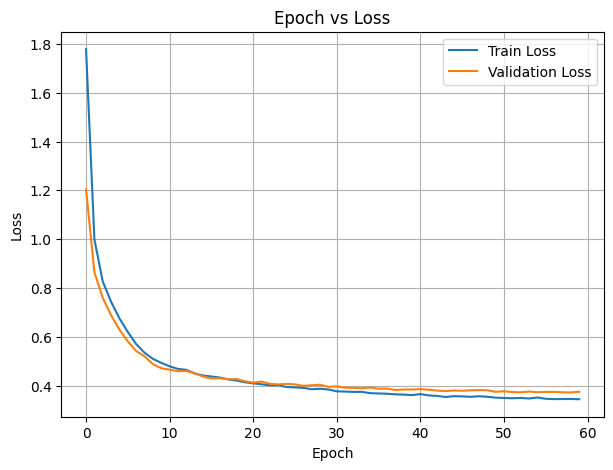

In [24]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

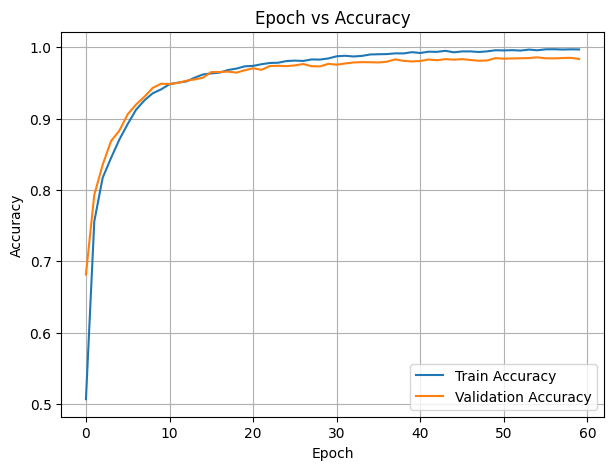

In [25]:
plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Epoch vs Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

In [26]:
def predict_by_batching(model, idx, batch_size, X, windowSize):

    preds=[]

    for i in tqdm(range(0,len(idx),batch_size)):

        batch = createImageCubes(X,idx[i:i+batch_size],windowSize)

        preds.append(model.predict(batch,verbose=0))

    return np.concatenate(preds)

100%|██████████| 265/265 [04:21<00:00,  1.01it/s]


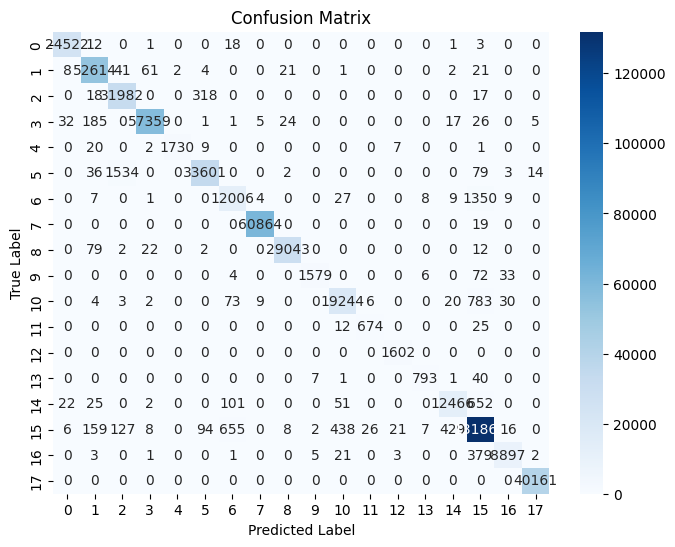

Overall Accuracy: 98.4
Average Accuracy: 96.96
Kappa: 98.17


In [27]:
Y_pred_test = predict_by_batching(model,X_test_idx,2000,data,window_size)

y_pred_test = np.argmax(Y_pred_test,axis=1)

oa = accuracy_score(y_test,y_pred_test)

kappa = cohen_kappa_score(y_test,y_pred_test)

cm = confusion_matrix(y_test,y_pred_test)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

class_acc = cm.diagonal()/cm.sum(axis=1)

aa = np.mean(class_acc)

print("Overall Accuracy:",round(oa*100,2))

print("Average Accuracy:",round(aa*100,2))

print("Kappa:",round(kappa*100,2))

In [28]:
import json

test_metrics = {
    "Overall Accuracy (OA)": float(oa),
    "Average Accuracy (AA)": float(aa),
    "Kappa Score": float(kappa)
}

with open("test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Test metrics saved.")

Test metrics saved.


In [29]:
from google.colab import files

files.download("test_metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import pandas as pd

cm_df = pd.DataFrame(cm, index=class_name, columns=class_name)

cm_df.to_csv("confusion_matrix_test.csv")

print("Confusion matrix saved.")

Confusion matrix saved.


In [31]:
from google.colab import files

files.download("confusion_matrix_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from sklearn.metrics import classification_report

In [33]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=class_name,
        digits=4
    )
)


Classification Report:

                    precision    recall  f1-score   support

      Rubber track     0.9972    0.9986    0.9979     24557
         Flaggingv     0.9897    0.9969    0.9933     52775
             Sandy     0.9493    0.9891    0.9688     32335
           Asphalt     0.9983    0.9949    0.9966     57655
         Boardwalk     0.9988    0.9780    0.9883      1769
    Rocky shallows     0.9874    0.9527    0.9698     35269
         Grassland     0.9337    0.8946    0.9137     13421
           Bulrush     0.9997    0.9997    0.9997     60883
       Gravel road     0.9981    0.9960    0.9970     29160
 Ligustrum vicaryi     0.9912    0.9321    0.9608      1694
   Coniferous pine     0.9722    0.9539    0.9629     20174
           Spiraea     0.9547    0.9480    0.9513       711
         Bare soil     0.9810    1.0000    0.9904      1602
      Buxus sinica     0.9742    0.9418    0.9577       842
Photinia serrulata     0.9630    0.9360    0.9493     13319
           Pop

In [34]:
import pandas as pd

report = classification_report(
    y_test,
    y_pred_test,
    target_names=class_name,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

df_report.to_csv("classification_report.csv")

pd.DataFrame(cm).to_csv("confusion_matrix.csv")

print("Results saved.")

Results saved.


In [35]:
import pandas as pd

report_df = pd.DataFrame(report).transpose()

report_df.to_csv("classification_report.csv")

print("Classification report saved.")

Classification report saved.


In [36]:
from google.colab import files

files.download("classification_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import pandas as pd
import numpy as np

# -----------------------------
# Compute per-class accuracy
# -----------------------------
class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

rows = []

for i in range(len(class_name)):

    train_count = (y_train.argmax(axis=1) == i).sum()
    val_count   = (y_val.argmax(axis=1) == i).sum()
    test_count  = (y_test == i).sum()
    total_count = (gt == (i+1)).sum()

    rows.append([
        class_name[i],
        train_count,
        val_count,
        test_count,
        total_count,
        round(class_accuracy[i], 2)
    ])

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame(
    rows,
    columns=[
        "Class",
        "Train",
        "Val",
        "Test",
        "Total",
        "SS-MixNet (%)"
    ]
)

# -----------------------------
# Summary Metrics
# -----------------------------
summary_rows = pd.DataFrame([
    ["OA (%)", "", "", "", "", round(oa * 100, 2)],
    ["AA (%)", "", "", "", "", round(aa * 100, 2)],
    ["Kappa (×100)", "", "", "", "", round(kappa * 100, 2)]
], columns=df.columns)

df_final = pd.concat([df, summary_rows], ignore_index=True)

# -----------------------------
# Pretty Print Table
# -----------------------------
print("\n")
print("=" * 90)
print(f"{'Classification Performance of SS-MixNet on ' + DATASET:^90}")
print("=" * 90)

print(f"{'Class':<25}{'Train':>8}{'Val':>8}{'Test':>10}{'Total':>10}{'Accuracy (%)':>15}")
print("-" * 90)

for i in range(len(class_name)):
    print(f"{df.iloc[i,0]:<25}"
          f"{df.iloc[i,1]:>8}"
          f"{df.iloc[i,2]:>8}"
          f"{df.iloc[i,3]:>10}"
          f"{df.iloc[i,4]:>10}"
          f"{df.iloc[i,5]:>15}")

print("-" * 90)

print(f"{'Overall Accuracy (OA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(oa*100,2):>15}")
print(f"{'Average Accuracy (AA)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(aa*100,2):>15}")
print(f"{'Kappa (×100)':<25}{'':>8}{'':>8}{'':>10}{'':>10}{round(kappa*100,2):>15}")

print("=" * 90)




                  Classification Performance of SS-MixNet on Tangdaowan                   
Class                       Train     Val      Test     Total   Accuracy (%)
------------------------------------------------------------------------------------------
Rubber track                  904     388     24557     25849          99.86
Flaggingv                    1945     833     52775     55553          99.69
Sandy                        1191     511     32335     34037          98.91
Asphalt                      2124     911     57655     60690          99.49
Boardwalk                      65      28      1769      1862           97.8
Rocky shallows               1299     557     35269     37125          95.27
Grassland                     494     212     13421     14127          89.46
Bulrush                      2243     961     60883     64087          99.97
Gravel road                  1075     460     29160     30695           99.6
Ligustrum vicaryi              62      27     

In [38]:
def get_class_map(model, X, label, window_size):

    indexes = np.argwhere(label != None)

    indexes = [tuple(i) for i in indexes]

    preds = []

    for i in tqdm(range(0, len(indexes), 2000)):
        batch_idx = indexes[i:i+2000]

        patches = createImageCubes(X, batch_idx, window_size)

        y_pred = model.predict(patches, verbose=0)

        preds.append(y_pred)

    preds = np.concatenate(preds)

    preds = np.argmax(preds, axis=1)

    Predicted_Class_Map = np.reshape(preds, label.shape)

    return Predicted_Class_Map

In [39]:
def img_display(data=None, rgb_band=None, classes=None, title=None, figsize=(7,7)):

    if data is not None:
        im_rgb = data[:,:,rgb_band]
        im_rgb = im_rgb / np.max(im_rgb) * 255
        im_rgb = np.asarray(im_rgb, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(im_rgb)
        plt.title(title)
        plt.axis('off')
        plt.show()

    elif classes is not None:

        unique_classes = np.unique(classes)

        rgb_class = np.zeros((classes.shape[0], classes.shape[1], 3))

        colors = spectral.spy_colors

        for i in unique_classes:
            rgb_class[classes == i] = colors[i]

        rgb_class = np.asarray(rgb_class, np.uint8)

        plt.figure(figsize=figsize)
        plt.imshow(rgb_class)
        plt.title(title)
        plt.axis('off')
        plt.show()

100%|██████████| 749/749 [11:42<00:00,  1.07it/s]


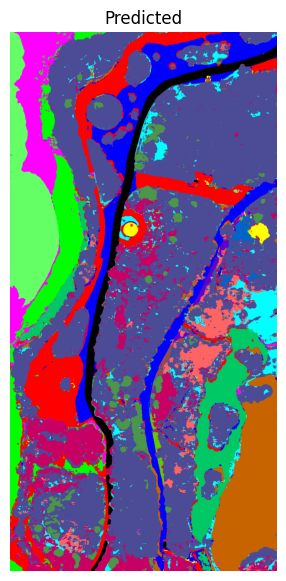

In [40]:
model.load_weights(f"{DATASET}_SS_MixNet_CBAM.keras")

Predicted_Class_Map = get_class_map(model, data, gt, window_size)

img_display(classes=Predicted_Class_Map, title='Predicted')

In [41]:
model.save("SS_MixNet_CBAM.keras")

from google.colab import files
files.download("SS_MixNet_CBAM.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
model.save_weights("SS_MixNet_CBAM_T4.weights.h5")

from google.colab import files
files.download("SS_MixNet_CBAM_T4.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import numpy as np

np.save("X_test_idx.npy", X_test_idx)
np.save("y_test.npy", y_test)

from google.colab import files
files.download("X_test_idx.npy")
files.download("y_test.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>